<a href="https://colab.research.google.com/github/mlhsumu/my-git-repo/blob/main/language_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
!pip install pandas scikit-learn nltk seaborn

import pandas as pd
import string
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
import pandas as pd

# Load dataset
df = pd.read_csv("language.csv")
df.head()


,Text,language
0,klement gottwaldi surnukeha palsameeriti ning ...,Estonian
1,sebes joseph pereira thomas på eng the jesuit...,Swedish
2,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...,Thai
3,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...,Tamil
4,de spons behoort tot het geslacht haliclona en...,Dutch


In [14]:
print("Total samples:", len(df))
print("languages:", df['language'].nunique())
print(df['language'].value_counts())

Total samples: 1715
languages: 22
language
Russian       100
Japanese       89
Latin          89
Dutch          85
Turkish        83
Portugese      83
Hindi          83
Tamil          81
Swedish        81
Persian        80
Urdu           77
Pushto         76
Spanish        74
English        74
Korean         74
Indonesian     72
French         72
Thai           71
Estonian       70
Arabic         70
Chinese        65
Romanian       65
Name: count, dtype: int64


In [37]:
def clean_text(text):
    text = text.lower()
    text = ''.join([ch for ch in text if ch not in string.punctuation])
    return text

df['clean_text'] = df['Text'].apply(clean_text)

In [38]:
# Drop rows with missing values in the 'language' column
df_cleaned = df.dropna(subset=['language']).copy()

vectorizer = CountVectorizer(analyzer='char', ngram_range=(1, 3), max_features=5000)
X = vectorizer.fit_transform(df_cleaned['clean_text'])
y = df_cleaned['language']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [40]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00        14
     Chinese       1.00      1.00      1.00        13
       Dutch       1.00      1.00      1.00        17
     English       0.75      1.00      0.86        15
    Estonian       1.00      1.00      1.00        14
      French       1.00      1.00      1.00        14
       Hindi       1.00      1.00      1.00        17
  Indonesian       1.00      0.93      0.96        14
    Japanese       1.00      1.00      1.00        18
      Korean       1.00      1.00      1.00        15
       Latin       1.00      1.00      1.00        18
     Persian       1.00      1.00      1.00        16
   Portugese       1.00      1.00      1.00        17
      Pushto       1.00      0.93      0.97        15
    Romanian       1.00      1.00      1.00        13
     Russian       1.00      1.00      1.00        20
     Spanish       1.00      1.00      1.00        15
     Swedish       1.00    

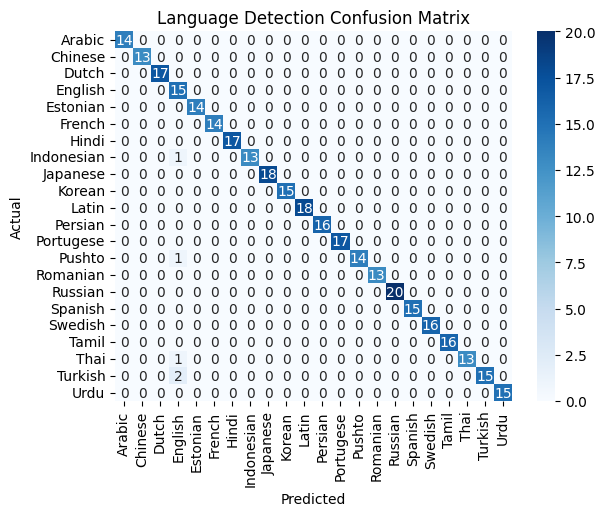

In [41]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=model.classes_, yticklabels=model.classes_, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Language Detection Confusion Matrix")
plt.show()

In [35]:
# Test on new text file

file_path = 'new_text.txt'  # Path to the text file

try:
    with open(file_path, "r", encoding="utf-8") as f:
        test_samples = [line.strip() for line in f.readlines() if line.strip()]

    # preprocess and predict
    test_samples_cleaned = [clean_text(msg) for msg in test_samples]

    test_features = vectorizer.transform(test_samples_cleaned)
    predictions = model.predict(test_features)

    # show results
    for msg, pred in zip(test_samples, predictions):
        print(f"Message: {msg}")
        print("Predicted Language:", pred)
        print("-" * 50)

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Message: Hello, how are you?
Predicted Language: English
--------------------------------------------------
Message: Hola, ¿cómo estás?
Predicted Language: Spanish
--------------------------------------------------
Message: Bonjour, comment ça va?
Predicted Language: French
--------------------------------------------------
Message: Hallo, wie geht es dir?
Predicted Language: Dutch
--------------------------------------------------
Message: Ciao, come stai?
Predicted Language: Portugese
--------------------------------------------------
